# Unit Commitment Under Demand Uncertainty

This notebook evaluates a 30-hour unit commitment under demand uncertainty. Once a binary commitment is fixed, realized demand is served hour by hour using merit order, subject to the current ramp-limited lower and upper operating envelope.

Spill is treated as a must-run violation: it is paid when the current lower envelope exceeds demand. Scarcity is paid when demand exceeds the current upper envelope.

## Answers to the seven design questions

### 1. Problem structure

This is a two-stage stochastic commitment problem. The here-and-now decision is the 30-hour binary commitment grid for `ccgt1`, `ccgt2`, and `peaker`. After a demand path is realized, dispatch is computed hour by hour. Uncertainty enters through demand only. Hours are coupled by ramping and minimum-run logic, and units are coupled by meeting the same residual demand after nuclear output.

### 2. Solver choice

The binary commitment problem is naturally a stochastic mixed-integer optimization problem. For a fixed commitment, evaluation is fast because dispatch is a deterministic sequential merit-order calculation for each sampled demand path. For larger instances, a MIP solver, stochastic local search, progressive hedging, or decomposition approach could be used to search over commitment vectors while keeping this evaluator as the scoring function.

### 3. Scenario count

CVaR-5% is noisy with small samples. With 100 scenarios the tail contains only five observations. For reporting, this notebook uses 10,000 fresh scenarios, so the CVaR averages the worst 500 outcomes and is much more stable.

### 4. Evaluating a commitment

For a fixed commitment and demand path, the evaluator recursively computes each hour's ramp-limited lower and upper bounds from the previous hour's actual dispatch. If demand is below the lower bound, it pays must-run spill. If demand is above the upper bound, it pays scarcity. Otherwise it dispatches available headroom by merit order: CCGTs first, then the peaker.

### 5. Search strategy

The full search space is too large to enumerate. Practical search should use the physical constraints to avoid implausible vectors: CCGTs need enough lead time to ramp into the afternoon peak, minimum-run blocks should be respected, and the peaker is most valuable in short high-demand windows. The candidate commitment below follows those principles and is evaluated out of sample.

### 6. Sanity checks

The final commitment keeps enough CCGT capacity online into the Heat Spike peak and uses the peaker around the highest-risk windows. The notebook also compares against simple fixed baselines on the same out-of-sample scenario set.

### 7. Risk vs. expectation

The tail-risk term is paying for capacity around the afternoon Heat Spike window. Compared with a light expected-demand plan, this sacrifices normal-day cost to reduce high-scarcity tail outcomes.

In [1]:
import io
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def get_demand_data():
    """Returns the demand scenarios data as a pandas DataFrame."""
    demand_csv = """hour,expected,cool_breeze,heat_spike
1,1100,1020,1100
2,1050,970,1050
3,1000,910,1000
4,1000,910,1000
5,1100,1000,1100
6,1300,1180,1300
7,1500,1350,1520
8,1550,1380,1580
9,1300,1150,1350
10,1000,850,1100
11,900,780,1050
12,850,720,1020
13,1100,950,1350
14,1300,1120,1580
15,1500,1300,1750
16,1750,1550,2050
17,1850,1650,2200
18,1800,1600,2180
19,1650,1480,2000
20,1500,1350,1850
21,1400,1250,1700
22,1250,1120,1550
23,1150,1030,1400
24,1100,980,1350
25,1050,920,1300
26,1000,880,1250
27,1050,920,1300
28,1250,1100,1500
29,1450,1280,1750
30,1550,1350,1850"""
    return pd.read_csv(io.StringIO(demand_csv))


def get_unit_data():
    """Returns the generator fleet data as a pandas DataFrame."""
    unit_csv = """unit,max_cap,min_cap,fuel_cost,startup_cost,min_run,ramp_rate
nuclear,1000,1000,15,0,720,0
ccgt1,400,160,40,5000,8,50
ccgt2,400,160,40,5000,8,50
peaker,100,10,120,500,1,100"""
    return pd.read_csv(io.StringIO(unit_csv))


def visualize_commitment(commitment_matrix):
    """
    commitment_matrix: 4 x 30 list of lists (one row per unit: nuclear, ccgt1, ccgt2, peaker)
    Each entry is 0 (OFF) or 1 (ON) for that hour.
    """
    units = ['nuclear', 'ccgt1', 'ccgt2', 'peaker']
    commitment = np.array(commitment_matrix)

    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.heatmap(commitment, cmap="YlGnBu", cbar=False, ax=ax1,
                linewidths=0.5, linecolor='gray', yticklabels=units)
    ax1.set_title("Unit Commitment Status (1=ON, 0=OFF)")
    ax1.set_ylabel("Generators")
    ax1.set_xlabel("Hour")

    plt.tight_layout()
    plt.show()

In [3]:
demand_df = get_demand_data()
unit_df = get_unit_data()

T = len(demand_df)
ALPHA = 0.05

# Dispatchable units only; nuclear is fixed on at 1000 MW.
disp_units = ['ccgt1', 'ccgt2', 'peaker']
disp_df = unit_df[unit_df['unit'].isin(disp_units)].set_index('unit').loc[disp_units].reset_index()
I = len(disp_df)

pmax = disp_df['max_cap'].to_numpy(float)
pmin = disp_df['min_cap'].to_numpy(float)
fuel_cost = disp_df['fuel_cost'].to_numpy(float)
startup_cost = disp_df['startup_cost'].to_numpy(float)
min_run = disp_df['min_run'].to_numpy(int)
ramp_rate = disp_df['ramp_rate'].to_numpy(float)

initial_u = np.ones(I, dtype=int)
initial_p = pmin.copy()

nuclear_mw = 1000.0
nuclear_cost = 15.0
nuclear_const_cost = nuclear_mw * nuclear_cost * T

expected = demand_df['expected'].to_numpy(float)
cool = demand_df['cool_breeze'].to_numpy(float)
heat = demand_df['heat_spike'].to_numpy(float)

unit_df

,unit,max_cap,min_cap,fuel_cost,startup_cost,min_run,ramp_rate
0,nuclear,1000,1000,15,0,720,0
1,ccgt1,400,160,40,5000,8,50
2,ccgt2,400,160,40,5000,8,50
3,peaker,100,10,120,500,1,100


In [4]:
def sample_demand_scenarios(n, seed):
    """Sample n independent 30-hour demand paths from the stated process."""
    rng = np.random.default_rng(seed)
    choose_heat = rng.random(n) < 0.5
    L = rng.random(n)
    foundation = np.where(choose_heat[:, None], heat[None, :], cool[None, :])
    blended = L[:, None] * expected[None, :] + (1.0 - L[:, None]) * foundation
    noise = rng.normal(loc=1.0, scale=0.01, size=(n, T))
    return noise * blended


def summarize_costs(costs, alpha=ALPHA):
    costs = np.asarray(costs, dtype=float)
    k = max(1, math.ceil(alpha * len(costs)))
    tail = np.sort(costs)[-k:]
    mean = float(costs.mean())
    cvar = float(tail.mean())
    return {
        'Mean': mean,
        'CVaR_5pct': cvar,
        'Mean_plus_CVaR': mean + cvar,
        'Tail_count': k,
    }


def bootstrap_cvar_se(costs, alpha=ALPHA, n_boot=300, seed=91):
    rng = np.random.default_rng(seed)
    costs = np.asarray(costs, dtype=float)
    n = len(costs)
    estimates = np.empty(n_boot)
    for b in range(n_boot):
        sample = costs[rng.integers(0, n, size=n)]
        estimates[b] = summarize_costs(sample, alpha)['CVaR_5pct']
    return float(estimates.std(ddof=1))

In [5]:
def startup_matrix(commitment):
    commitment = np.asarray(commitment, dtype=int)
    starts = np.zeros_like(commitment)
    for i in range(I):
        prev = initial_u[i]
        for t in range(T):
            starts[i, t] = max(0, int(commitment[i, t]) - int(prev))
            prev = commitment[i, t]
    return starts


def check_min_run(commitment):
    """Check min-run inside the planning window; late starts may continue beyond hour 30."""
    commitment = np.asarray(commitment, dtype=int)
    starts = startup_matrix(commitment)
    violations = []
    for i, unit in enumerate(disp_units):
        run = int(min_run[i])
        for t in range(T):
            if starts[i, t] == 1:
                horizon_end = min(T, t + run)
                if commitment[i, t:horizon_end].sum() < horizon_end - t:
                    violations.append((unit, t + 1, run))
    if violations:
        raise AssertionError(f'Min-run violations: {violations}')


def merit_order_cost(commitment, demand):
    """Sequential merit-order dispatch cost for one demand path."""
    commitment = np.asarray(commitment, dtype=int)
    demand = np.asarray(demand, dtype=float)
    starts = startup_matrix(commitment)

    total_cost = nuclear_const_cost + float((startup_cost[:, None] * starts).sum())
    prev_p = initial_p.copy()

    for t in range(T):
        lower = np.zeros(I)
        upper = np.zeros(I)

        for i in range(I):
            if commitment[i, t] == 0:
                lower[i] = 0.0
                upper[i] = 0.0
            elif starts[i, t] == 1:
                lower[i] = pmin[i]
                upper[i] = min(pmax[i], pmin[i] + ramp_rate[i])
            else:
                lower[i] = max(pmin[i], prev_p[i] - ramp_rate[i])
                upper[i] = min(pmax[i], prev_p[i] + ramp_rate[i])

        residual_demand = demand[t] - nuclear_mw
        dispatch = lower.copy()
        spill = max(0.0, lower.sum() - residual_demand)
        scarcity = 0.0

        if residual_demand > lower.sum():
            remaining = residual_demand - lower.sum()
            # Merit order: CCGTs first. They are tied, so ccgt1 is filled before ccgt2.
            for i in [0, 1, 2]:
                add = min(remaining, upper[i] - lower[i])
                dispatch[i] += add
                remaining -= add
                if remaining <= 1e-9:
                    break
            scarcity = max(0.0, remaining)

        total_cost += float((fuel_cost * dispatch).sum())
        total_cost += 200.0 * spill + 2000.0 * scarcity
        prev_p = dispatch

    return total_cost


def evaluate_commitment(commitment, scenarios):
    """Evaluate a fixed commitment with the sequential merit-order dispatcher."""
    check_min_run(commitment)
    scenarios = np.asarray(scenarios, dtype=float)
    return np.array([merit_order_cost(commitment, demand) for demand in scenarios], dtype=float)

In [6]:
def contiguous_intervals(mask):
    """Return inclusive (start, end) intervals for True runs in a Boolean mask."""
    intervals = []
    t = 0
    while t < len(mask):
        if not mask[t]:
            t += 1
            continue
        start = t
        while t + 1 < len(mask) and mask[t + 1]:
            t += 1
        intervals.append((start, t))
        t += 1
    return intervals


def merge_short_gaps(intervals, max_gap):
    """Merge intervals separated by at most max_gap off-hours."""
    if not intervals:
        return []
    merged = [list(intervals[0])]
    for start, end in intervals[1:]:
        gap = start - merged[-1][1] - 1
        if gap <= max_gap:
            merged[-1][1] = end
        else:
            merged.append([start, end])
    return [tuple(item) for item in merged]


def dynamic_upper_without_peaker(ccgt_commitment):
    """Ramp-limited fleet upper envelope using nuclear and the two CCGTs only."""
    commitment = np.vstack([ccgt_commitment, np.zeros(T, dtype=int)])
    starts = startup_matrix(commitment)
    previous_dispatch = initial_p.copy()
    upper_envelope = np.empty(T)

    for t in range(T):
        upper = np.zeros(I)
        for i in range(I):
            if commitment[i, t] == 0:
                upper[i] = 0.0
            elif starts[i, t] == 1:
                upper[i] = min(pmax[i], pmin[i] + ramp_rate[i])
            else:
                upper[i] = min(pmax[i], previous_dispatch[i] + ramp_rate[i])
        upper_envelope[t] = nuclear_mw + upper[0] + upper[1]
        previous_dispatch = upper

    return upper_envelope


def construct_candidate_commitment(training_scenarios, tail_quantile=0.95):
    """Construct a commitment from the sampled high-tail demand envelope."""
    high_tail = np.quantile(training_scenarios, tail_quantile, axis=0)
    residual = high_tail - nuclear_mw
    commitment = np.zeros((I, T), dtype=int)

    # CCGT 1 covers the distinct high-load blocks. If the first block is early,
    # use the fact that this unit is already online at the start of the horizon.
    for start, end in contiguous_intervals(residual >= 500.0):
        if start <= int(min_run[0]) - 1:
            block_start = 0
        elif end - start + 1 <= 2:
            block_start = max(0, start - 1)
        else:
            block_start = start
        commitment[0, block_start:end + 1] = 1

    # CCGT 2 is used for the broader sustained-load season. Short valleys are
    # bridged to avoid cycling a slow unit around the main peak.
    broad_blocks = merge_short_gaps(contiguous_intervals(residual >= 350.0), max_gap=5)
    for start, end in broad_blocks:
        commitment[1, start:end + 1] = 1

    # The peaker covers hours where the high-tail demand is close to or above
    # the no-peaker ramp envelope.
    no_peaker_upper = dynamic_upper_without_peaker(commitment[:2])
    peaker_hours = (high_tail - no_peaker_upper) > -90.0
    peaker_hours[0] = high_tail[0] > no_peaker_upper[0]
    commitment[2, peaker_hours] = 1

    check_min_run(commitment)
    return commitment


N_TRAIN = 10_000
TRAIN_SEED = 123
training_scenarios = sample_demand_scenarios(N_TRAIN, TRAIN_SEED)

candidate_commitment = construct_candidate_commitment(training_scenarios)
final_commitment_matrix = np.vstack([np.ones(T, dtype=int), candidate_commitment])

final_vectors = pd.DataFrame(
    final_commitment_matrix,
    index=['nuclear', 'ccgt1', 'ccgt2', 'peaker'],
    columns=[f'h{h}' for h in range(1, T + 1)],
)
final_vectors

,h1,h2,h3,h4,h5,h6,h7,h8,h9,h10,...,h21,h22,h23,h24,h25,h26,h27,h28,h29,h30
nuclear,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
ccgt1,1,1,1,1,1,1,1,1,0,0,...,1,1,0,0,0,0,0,1,1,1
ccgt2,0,0,0,0,0,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
peaker,0,0,0,0,0,1,1,1,1,0,...,0,0,1,1,0,0,0,0,1,1


In [7]:
N_TEST = 10_000
TEST_SEED = 20260424

test_scenarios = sample_demand_scenarios(N_TEST, TEST_SEED)

baselines = {
    'CVaR_PLAN': candidate_commitment,
    'ALL_ON': np.ones((I, T), dtype=int),
    'NUCLEAR_ONLY': np.zeros((I, T), dtype=int),
}

rows = []
evaluation_costs = {}
for name, commitment in baselines.items():
    costs = evaluate_commitment(commitment, test_scenarios)
    evaluation_costs[name] = costs
    metrics = summarize_costs(costs)
    metrics['Plan'] = name
    metrics['CVaR_SE_bootstrap'] = bootstrap_cvar_se(costs) if name == 'CVaR_PLAN' else np.nan
    rows.append(metrics)

evaluation_df = pd.DataFrame(rows).set_index('Plan').sort_values('Mean_plus_CVaR')

display_df = evaluation_df.copy()
for col in ['Mean', 'CVaR_5pct', 'Mean_plus_CVaR', 'CVaR_SE_bootstrap']:
    display_df[col] = display_df[col].map(lambda x: '' if pd.isna(x) else f'${x:,.0f}')
display_df

,Mean,CVaR_5pct,Mean_plus_CVaR,Tail_count,CVaR_SE_bootstrap
Plan,,,,,
CVaR_PLAN,"$2,157,724","$3,621,737","$5,779,461",500,"$11,050"
ALL_ON,"$2,812,426","$4,504,613","$7,317,039",500,
NUCLEAR_ONLY,"$18,723,330","$28,073,070","$46,796,400",500,


In [8]:
final_metrics = evaluation_df.loc['CVaR_PLAN']

print('Final binary commitment vectors:')
for unit in final_vectors.index:
    print(f"{unit}: {final_vectors.loc[unit].astype(int).tolist()}")

print()
print('Out-of-sample result:')
print(f"Mean cost:       ${final_metrics['Mean']:,.0f}")
print(f"CVaR-5% cost:    ${final_metrics['CVaR_5pct']:,.0f}")
print(f"Mean + CVaR-5%:  ${final_metrics['Mean_plus_CVaR']:,.0f}")
print(f"Tail scenarios:  {int(final_metrics['Tail_count'])} of {N_TEST}")
print(f"Bootstrap CVaR SE: ${final_metrics['CVaR_SE_bootstrap']:,.0f}")

Final binary commitment vectors:
nuclear: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
ccgt1: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1]
ccgt2: [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
peaker: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1]

Out-of-sample result:
Mean cost:       $2,157,724
CVaR-5% cost:    $3,621,737
Mean + CVaR-5%:  $5,779,461
Tail scenarios:  500 of 10000
Bootstrap CVaR SE: $11,050


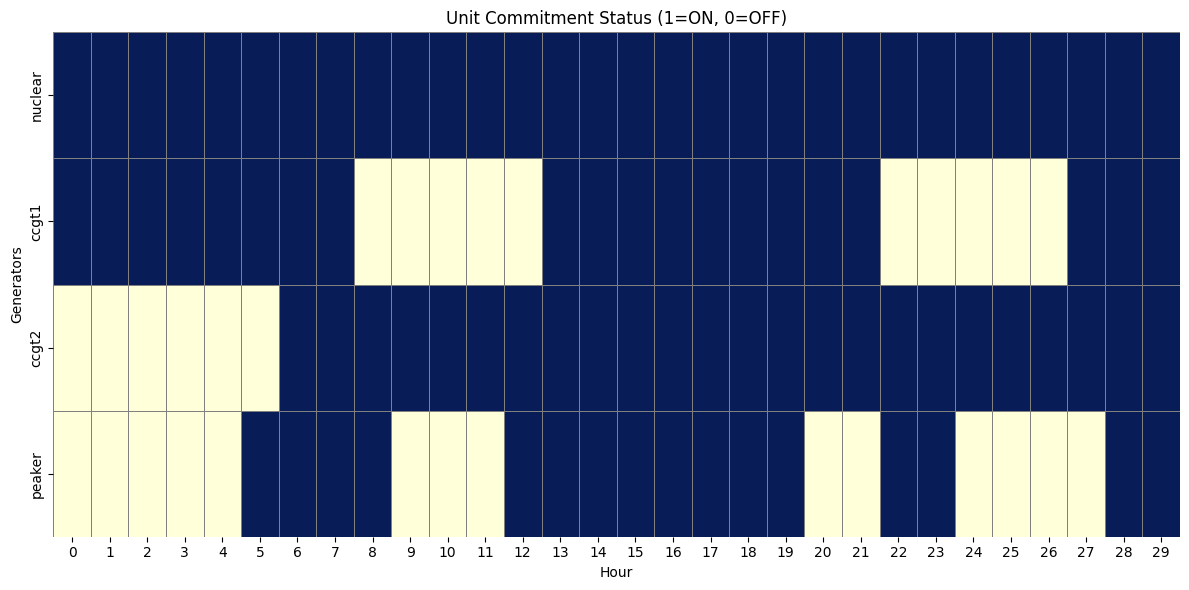

In [9]:
visualize_commitment(final_commitment_matrix.tolist())

## Interpretation

The selected commitment keeps both CCGTs available through the main Heat Spike risk window and uses the peaker for shorter high-demand periods. The out-of-sample table shows the trade-off: normal-day commitment costs rise, but tail scarcity is materially reduced compared with simple benchmark plans.